In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

ds = load_dataset("lukebarousse/data_jobs")

README.md:   0%|          | 0.00/3.25k [00:00<?, ?B/s]

data_jobs.csv: reconstructing file:   0%|          |  0.00B /  231MB            

data_jobs.csv: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/785741 [00:00<?, ? examples/s]

In [2]:
print(type(ds))
ds.keys()

<class 'datasets.dataset_dict.DatasetDict'>


dict_keys(['train'])

In [3]:
df = ds["train"].to_pandas()

In [4]:
df.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,None,NaN,NaN,Boehringer Ingelheim,None,None
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,None,NaN,NaN,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,None,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,None,NaN,NaN,Kristina Daniel,"['bash', 'python', 'oracle', 'aws', 'ansible',...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."


In [5]:
df["job_posted_date"]= pd.to_datetime(df["job_posted_date"])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  object        
 1   job_title              785740 non-null  object        
 2   job_location           784696 non-null  object        
 3   job_via                785733 non-null  object        
 4   job_schedule_type      773074 non-null  object        
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  object        
 7   job_posted_date        785741 non-null  datetime64[ns]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  object        
 11  salary_rate            33067 non-null   object        
 12  salary_year_avg        22003 non-null   floa

In [7]:
type(df["job_skills"][100])

str

In [11]:
import ast
def convert_string_to_list(string):
  if string and type(string) == str:
    return ast.literal_eval(string)
  return string

df["job_skills"] = df["job_skills"].apply(convert_string_to_list)


In [12]:
type(df["job_skills"][100])

list

In [15]:
df["month"] = df["job_posted_date"].dt.strftime(format("%B"))

In [16]:
df["month"]

,month
0,June
1,January
2,October
3,July
4,August
...,...
785736,March
785737,March
785738,March
785739,March


In [20]:
df_exploded = df.explode("job_skills")

In [32]:
df_exploded.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,month
108804,Data Analyst,Data Analyst,"New York, NY",via CareerBuilder,Full-time,False,"New York, United States",2023-01-01 00:00:04,False,False,United States,None,NaN,NaN,Metasys Technologies,snowflake,"{'analyst_tools': ['visio'], 'async': ['jira',...",January
108804,Data Analyst,Data Analyst,"New York, NY",via CareerBuilder,Full-time,False,"New York, United States",2023-01-01 00:00:04,False,False,United States,None,NaN,NaN,Metasys Technologies,confluence,"{'analyst_tools': ['visio'], 'async': ['jira',...",January
108804,Data Analyst,Data Analyst,"New York, NY",via CareerBuilder,Full-time,False,"New York, United States",2023-01-01 00:00:04,False,False,United States,None,NaN,NaN,Metasys Technologies,jira,"{'analyst_tools': ['visio'], 'async': ['jira',...",January
108804,Data Analyst,Data Analyst,"New York, NY",via CareerBuilder,Full-time,False,"New York, United States",2023-01-01 00:00:04,False,False,United States,None,NaN,NaN,Metasys Technologies,sql,"{'analyst_tools': ['visio'], 'async': ['jira',...",January
108804,Data Analyst,Data Analyst,"New York, NY",via CareerBuilder,Full-time,False,"New York, United States",2023-01-01 00:00:04,False,False,United States,None,NaN,NaN,Metasys Technologies,visio,"{'analyst_tools': ['visio'], 'async': ['jira',...",January


In [33]:
df_exploded = df_exploded.sort_values(by="job_posted_date")

In [36]:
df_exploded.reset_index(inplace=True)

In [37]:
df_exploded.set_index("month", inplace=True)

In [39]:
df_exploded.head()

,index,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
month,,,,,,,,,,,,,,,,,,
January,108804,Data Analyst,Data Analyst,"New York, NY",via CareerBuilder,Full-time,False,"New York, United States",2023-01-01 00:00:04,False,False,United States,None,NaN,NaN,Metasys Technologies,snowflake,"{'analyst_tools': ['visio'], 'async': ['jira',..."
January,108804,Data Analyst,Data Analyst,"New York, NY",via CareerBuilder,Full-time,False,"New York, United States",2023-01-01 00:00:04,False,False,United States,None,NaN,NaN,Metasys Technologies,confluence,"{'analyst_tools': ['visio'], 'async': ['jira',..."
January,108804,Data Analyst,Data Analyst,"New York, NY",via CareerBuilder,Full-time,False,"New York, United States",2023-01-01 00:00:04,False,False,United States,None,NaN,NaN,Metasys Technologies,jira,"{'analyst_tools': ['visio'], 'async': ['jira',..."
January,108804,Data Analyst,Data Analyst,"New York, NY",via CareerBuilder,Full-time,False,"New York, United States",2023-01-01 00:00:04,False,False,United States,None,NaN,NaN,Metasys Technologies,sql,"{'analyst_tools': ['visio'], 'async': ['jira',..."
January,108804,Data Analyst,Data Analyst,"New York, NY",via CareerBuilder,Full-time,False,"New York, United States",2023-01-01 00:00:04,False,False,United States,None,NaN,NaN,Metasys Technologies,visio,"{'analyst_tools': ['visio'], 'async': ['jira',..."


In [40]:
df_exploded.groupby(["month","job_skills"]).count()

index  job_title_short  job_title  job_location  \
month     job_skills                                                    
April     airflow      3805             3805       3805          3800   
          airtable       17               17         17            17   
          alteryx      1068             1068       1068          1067   
          angular       491              491        491           491   
          angular.js     14               14         14            14   
...                     ...              ...        ...           ...   
September wrike           3                3          3             3   
          wsl            14               14         14            14   
          xamarin         8                8          8             8   
          yarn          169              169        169           169   
          zoom          129              129        129           129   

                      job_via  job_schedule_type  job_work_from_home  \
month     job_skills                                                   
April     airflow        3805               3759                3805   
          airtable         17                 17                  17   
          alteryx        1068               1044                1068   
          angular         491                488                 491   
          angular.js       14                 14                  14   
...                       ...                ...                 ...   
September wrike             3                  3                   3   
          wsl              14                 14                  14   
          xamarin           8                  8                   8   
          yarn            169                167                 169   
          zoom            129                125                 129   

                      search_location  job_posted_date  job_no_degree_mention  \
month     job_skills                                                            
April     airflow                3805             3805                   3805   
          airtable                 17               17                     17   
          alteryx                1068             1068                   1068   
          angular                 491              491                    491   
          angular.js               14               14                     14   
...                               ...              ...                    ...   
September wrike                     3                3                      3   
          wsl                      14               14                     14   
          xamarin                   8                8                      8   
          yarn                    169              169                    169   
          zoom                    129              129                    129   

                      job_health_insurance  job_country  salary_rate  \
month     job_skills                                                   
April     airflow                     3805         3805          167   
          airtable                      17           17            0   
          alteryx                     1068         1068           45   
          angular                      491          491            9   
          angular.js                    14           14            0   
...                                    ...          ...          ...   
September wrike                          3            3            0   
          wsl                           14           14            0   
          xamarin                        8            8            0   
          yarn                         169          169            7   
          zoom                         129          129           11   

                      salary_year_avg  salary_hour_avg  company_name  \
month     job_skills                                                   


In [47]:
top_skills = df_exploded["job_skills"].value_counts().head(6).index.to_list()
top_skills

['sql', 'python', 'aws', 'azure', 'r', 'tableau']

In [52]:
df_top_skills = df_exploded[(df_exploded["job_skills"].isin(top_skills))]

In [53]:
df_top_skills.sample(20)

,index,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
month,,,,,,,,,,,,,,,,,,
January,461028,Senior Data Scientist,"Sr. Data Scientist, Legal Compliance","Frisco, TX",via Adzuna,Full-time,False,Sudan,2023-01-04 00:08:20,False,False,Sudan,None,NaN,NaN,T Mobile,tableau,"{'analyst_tools': ['tableau', 'power bi', 'qli..."
November,346967,Data Analyst,Remote Jr Java programmer/Data Analyst/Data Sc...,"Atlanta, GA",via Monster,Full-time,False,Georgia,2023-11-09 00:01:07,False,False,United States,year,90000.0,NaN,SynergisticIT,python,"{'analyst_tools': ['sas', 'tableau'], 'cloud':..."
December,182508,Data Scientist,Data Scientist- Tech & Tools,Anywhere,via JobTeaser,Full-time,True,Sweden,2023-12-01 15:36:54,False,False,Sweden,None,NaN,NaN,Epidemic Sound,python,"{'analyst_tools': ['looker'], 'libraries': ['a..."
August,737461,Data Analyst,Data Analytics,"Arlington, TX",via BeBee,Full-time,False,"Texas, United States",2023-08-06 21:23:28,False,False,United States,None,NaN,NaN,Association Analytics,aws,"{'analyst_tools': ['power bi', 'tableau'], 'cl..."
April,262277,Senior Data Scientist,Senior data scientist,"Atlanta, GA",via BeBee,None,False,"Florida, United States",2023-04-30 07:04:13,False,True,United States,None,NaN,NaN,Matlen Silver,python,"{'cloud': ['aws', 'azure', 'databricks'], 'pro..."
January,576487,Senior Data Engineer,Senior Data Engineer - Principal Associate (Re...,"San Francisco, CA",via LinkedIn,Internship,False,Georgia,2023-01-06 10:11:48,False,True,United States,None,NaN,NaN,Capital One,python,"{'cloud': ['redshift', 'snowflake', 'aws', 'az..."
May,378198,Data Engineer,Data Engineer,"Mexico City, CDMX, Mexico","via Trabajo.org - Vacantes De Empleo, Trabajo",Full-time,False,Mexico,2023-05-12 18:51:51,True,False,Mexico,None,NaN,NaN,Axity,azure,"{'cloud': ['gcp', 'azure', 'oracle'], 'databas..."
June,306249,Data Engineer,Data Engineer,"Kuala Lumpur, Federal Territory of Kuala Lumpu...",via BeBee Malaysia,Full-time,False,Malaysia,2023-06-20 17:19:46,False,False,Malaysia,None,NaN,NaN,Pos Malaysia Berhad,aws,"{'cloud': ['aws', 'redshift'], 'programming': ..."
January,689090,Cloud Engineer,Web Analyst,"Ramat Gan, Israel",via Comeet,Full-time,False,Israel,2023-01-12 11:14:58,True,False,Israel,None,NaN,NaN,Elementor,sql,"{'analyst_tools': ['looker'], 'programming': [..."


In [75]:
df_pivot = df_top_skills.pivot_table(
    index=df_top_skills.index,
    columns="job_skills",
    aggfunc="size",
    sort=False
)

In [76]:
df_pivot

job_skills,sql,r,python,azure,tableau,aws
month,,,,,,
January,45774,16351,44889,15385,14805,16805
February,32720,11288,31943,11114,11008,12219
March,32282,11358,31990,11152,10870,12458
April,31096,10647,30482,10557,10430,11635
May,27096,9339,26908,9111,9236,10394
June,31671,10820,31216,10793,10575,11759
July,31869,10793,31257,10960,10758,12017
August,36699,13037,36228,12193,12497,13817
September,28926,9248,28616,10221,9344,10934


<Axes: xlabel='month'>

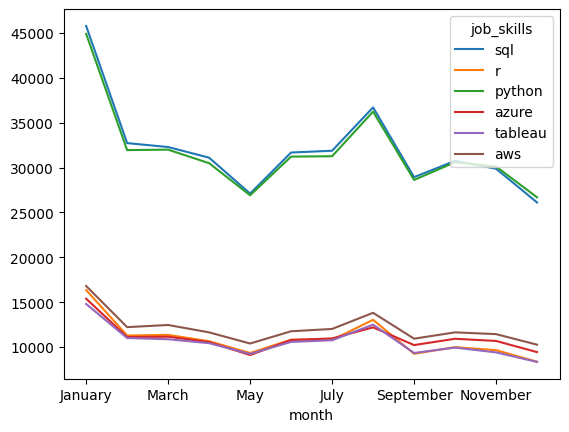

In [77]:
df_pivot.plot()